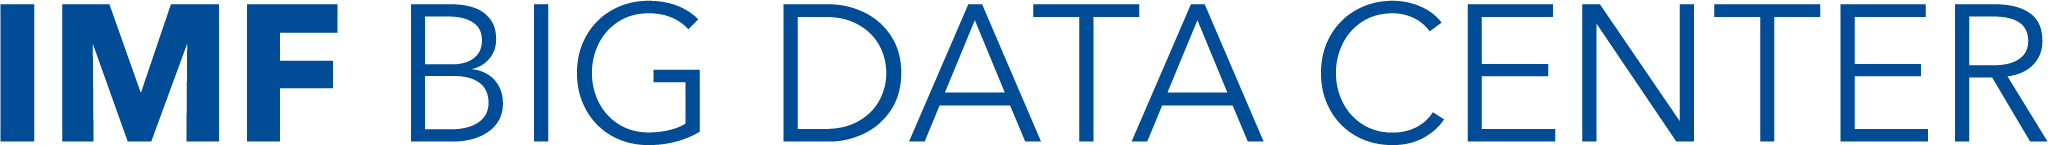

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/AlessandraSozzi/BDC_STI_26/blob/main/notebooks/BDC_GDP_Nowcasting_ML_Workflow.ipynb)

# Nowcasting GDP Using Satellite Data and Machine Learning

---

<br>**Contributors:** [Iyke Maduako](imaduako@imf.org), [Alberto Sanchez](asanchez3@imf.org), [Alessandra Sozzi](asozzi@imf.org)
<br> **Last update:** 2025-10-23 (Created: 2025-May)
<br> **Description:** This notebook shows how to process, train a nowcast model, evaluate performance, explain results, and retrain when new observations are available. Useful in the context of the IMF's NowHub framework.
<br> **References:**

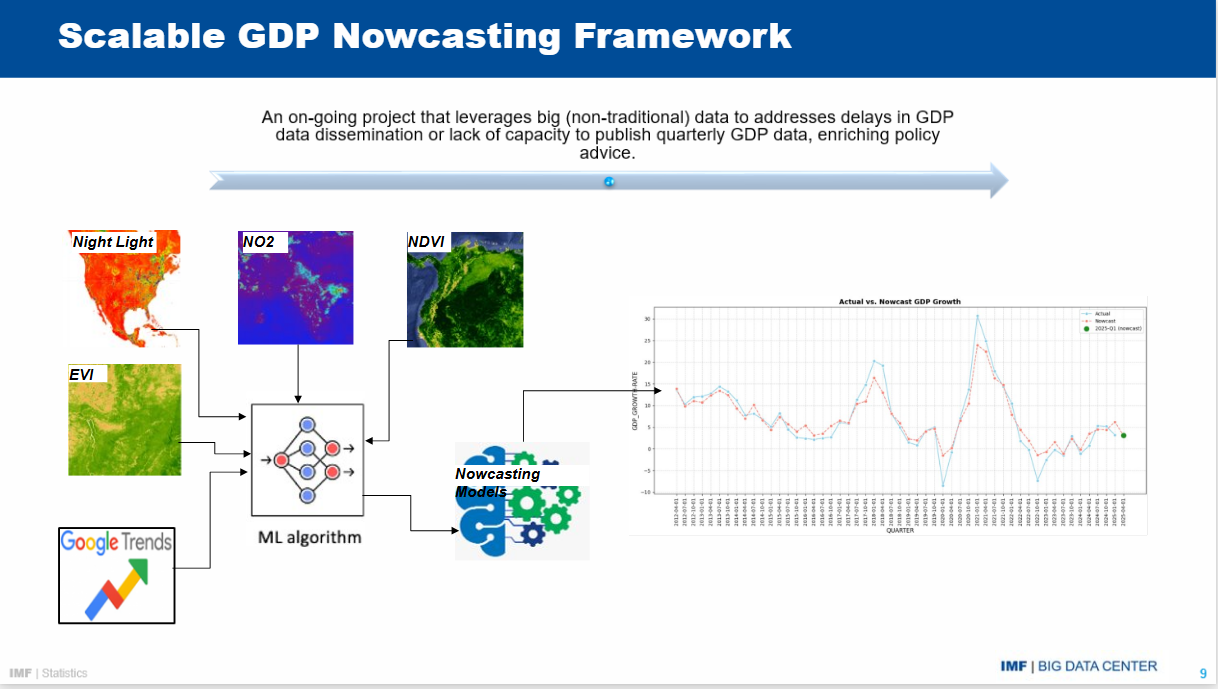

## Set-up

Mount Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### Install and import libraries.

⚠ **May need to restart session**

In [2]:
#install shapley and pdp packages
!pip install shap pdpbox

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.8/35.8 MB 43.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.9/64.9 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.7/7.7 MB 81.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.1/121.1 kB 7.9 MB/s eta 0:00:00


Import Packages

In [1]:
# import related libraries
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error
from keras.models import Sequential
from keras.layers import Dense
from keras.layers import LSTM
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import MinMaxScaler
import pandas as pd
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt # Moved this import here
import math
from pandas import DataFrame
from pandas import concat
from numpy import concatenate
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import RandomizedSearchCV
import pdpbox.pdp as pdp
import shap
import time
import pickle
import shap
import os
from PIL import Image
from sklearn.model_selection import TimeSeriesSplit
from pdpbox import pdp, get_example, info_plots
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
import numpy as np
from sklearn.metrics import mean_absolute_error

### Import data

<h3> ⏰ Don't forget to adjust the path </h3>

In [2]:
ROOT = "/content/drive/MyDrive/STI 2026/" #if using colab

workspace = "Day 2-3 - GDP Nowcasting/"
data_folder = "Data/Model Data/"
data_path = os.path.join(ROOT, workspace, data_folder)
data_path
os.path.exists(data_path)

True

We use Nigeria in this notebook

In [3]:
CountryName = "Nigeria"

▶ *Remember you can use 'BDC_Data_Extract_Satellite_Data' and 'BDC_Data_Preprocessing_for_GDP_Nowcasting' to extract and process data for another country. However, data extraction may take long.*

In [4]:
# Read the CSV file into a Pandas DataFrame
filename = 'model_data_nga.csv'
filepath = os.path.join(data_path, filename)
df_imported = pd.read_csv(filepath)

#df_imported.drop(columns=['Month', 'Year_current'], inplace=True)
df_imported
df=df_imported
df.index=df.index.astype(str)

In [5]:
df.describe()

,year_current,month,diff_gti_tourism,diff_sum_no2,diff_mean_no2,diff_sum_ndvi,diff_mean_ndvi,diff_sum_evi,diff_mean_evi,diff_sum_ntl,...,diff_sum_pcp,diff_sum_asi,diff_mean_asi,diff_sum_ndvi_anomaly,diff_mean_ndvi_anomaly,diff_sum_vhi,diff_mean_vhi,diff_decom_gti_tourism,diff_diff_gti_tourism,GDP
count,5.300000e+01,53.000000,53.000000,53.000000,53.000000,53.000000,53.000000,53.000000,53.000000,53.000000,...,53.000000,53.000000,53.000000,53.000000,53.000000,53.000000,53.000000,53.000000,53.000000,51.000000
mean,2.018334e+11,19.245283,34.840038,4.109014,-9.502204,31.791322,5.653298,31.193751,5.773093,3.405359,...,59.455029,192.143546,192.601086,1.009979,1.003738,3.443461,3.445396,34.860406,-171.103594,2.539618
std,3.863614e+08,10.231749,68.324936,67.127220,71.070795,245.818431,45.802903,241.347690,46.341097,44.205367,...,196.757061,660.434150,659.939691,17.688515,17.649748,31.137598,31.135661,68.301294,439.306015,2.529964
min,2.012201e+11,6.000000,-78.652251,-188.066217,-185.465258,-95.547610,-44.373085,-95.509549,-40.928544,-86.768883,...,-166.231287,-258.360169,-258.360169,-42.180131,-42.180131,-81.084306,-81.084306,-77.572756,-883.333333,-4.675934
25%,2.015202e+11,6.000000,-2.272727,-27.836809,-28.495908,-8.934428,-8.799409,-8.343968,-8.313387,-28.309233,...,-13.288956,-69.426358,-70.705355,-8.236498,-8.236498,-15.860160,-15.860160,-2.585050,-377.382429,1.457716
50%,2.018202e+11,15.000000,22.222222,-3.856199,-3.857971,-0.953199,-0.085817,-1.027604,-0.976661,3.326565,...,8.360083,39.476162,34.684847,1.457267,0.823904,1.129075,1.621511,23.591364,-234.926724,2.752049
75%,2.021202e+11,24.000000,56.277056,40.671151,16.649810,7.624957,7.612829,10.418058,10.357442,27.485032,...,81.080710,171.015102,171.015102,7.723424,7.723424,14.983615,14.983615,55.456786,-102.606788,4.177148
max,2.025203e+11,33.000000,312.525710,192.936238,193.929384,1782.383110,316.079667,1749.373233,319.208814,158.608725,...,1249.107297,4331.480256,4331.480256,59.078159,59.078159,95.365152,95.365152,310.290188,1424.836601,6.645603


In [6]:
df_imported.tail()

,index,year_current,month,diff_gti_tourism,diff_sum_no2,diff_mean_no2,diff_sum_ndvi,diff_mean_ndvi,diff_sum_evi,diff_mean_evi,...,diff_sum_pcp,diff_sum_asi,diff_mean_asi,diff_sum_ndvi_anomaly,diff_mean_ndvi_anomaly,diff_sum_vhi,diff_mean_vhi,diff_decom_gti_tourism,diff_diff_gti_tourism,GDP
48,2024-04-01,202420242024,6,-3.908669,-3.856199,-3.857971,-95.547610,-44.373085,-95.509549,-40.928544,...,95.864678,87.696363,97.026934,-17.502403,-17.502403,-15.907226,-15.907226,-2.829173,-273.893529,3.143663
49,2024-07-01,202420242024,15,-26.580087,19.097267,18.955709,-17.040362,-17.011761,-15.038930,-15.009525,...,2.791961,57.865846,59.889135,-19.561049,-19.561049,-14.705117,-14.705117,-28.815608,-167.070707,3.195526
50,2024-10-01,202420242024,24,-15.062389,-188.066217,-185.465258,-28.632328,0.987654,-35.424417,-7.329526,...,-25.013640,75.219780,79.279791,-15.552535,-15.552535,-10.434478,-10.434478,-13.594041,-217.080469,4.352861
51,2025-01-01,202420242024,33,-6.451613,-110.427821,-110.095880,11.715487,11.736998,11.796296,11.817849,...,-54.837019,40.436217,33.654146,16.342595,16.342595,30.908788,30.908788,-6.763935,-216.048387,NaN
52,2025-04-01,202520252025,6,-7.822712,46.801992,46.801992,1782.383110,316.079667,1749.373233,319.208814,...,254.907679,-49.839386,-51.391123,-22.281404,-22.281404,-7.286102,-7.286102,-6.743217,-492.177288,NaN


### Data processing

In [7]:
column_list = df.columns.tolist()
print(column_list)

['index', 'year_current', 'month', 'diff_gti_tourism', 'diff_sum_no2', 'diff_mean_no2', 'diff_sum_ndvi', 'diff_mean_ndvi', 'diff_sum_evi', 'diff_mean_evi', 'diff_sum_ntl', 'diff_mean_ntl', 'diff_mean_pcp', 'diff_sum_pcp', 'diff_sum_asi', 'diff_mean_asi', 'diff_sum_ndvi_anomaly', 'diff_mean_ndvi_anomaly', 'diff_sum_vhi', 'diff_mean_vhi', 'diff_decom_gti_tourism', 'diff_diff_gti_tourism', 'GDP']


Keep only relevant columns

<h3> <b>❓ Would you keep both instances of Satellite Data aggregations: Mean and Sum? Why? Why not?
</b>

In [8]:
col = ['index', 'year_current', 'diff_sum_ntl', 'diff_sum_evi', 'diff_sum_ndvi', 'diff_sum_no2', 'diff_sum_pcp', 'diff_sum_asi', 'diff_sum_ndvi_anomaly', 'diff_sum_vhi', 'diff_gti_tourism', 'GDP']
df = df[col]

In [9]:
# year as string
df['year_current'] = df['year_current'].astype(str).str[:4]
df.rename(columns={'year_current': 'year'}, inplace=True)


▶ Data is already pre-processed: imputed missing values and taken differences to make them stationary. Reference: 'BDC_Data_Processing_for_GDP_Nowcasting'.

In [10]:
df.tail(12)

,index,year,diff_sum_ntl,diff_sum_evi,diff_sum_ndvi,diff_sum_no2,diff_sum_pcp,diff_sum_asi,diff_sum_ndvi_anomaly,diff_sum_vhi,diff_gti_tourism,GDP
41,2022-07-01,2022,39.002218,10.647988,7.624957,-42.197817,51.620739,-177.044347,14.841333,50.230434,68.260057,2.725813
42,2022-10-01,2022,-28.273493,-7.265753,-7.526036,-96.923583,-12.582556,-54.224133,3.509304,4.644882,39.222659,3.085271
43,2023-01-01,2022,58.372397,1.450241,-4.684446,-7.436858,31.078907,95.785722,-0.385452,7.339596,-43.328178,2.424850
44,2023-04-01,2023,44.702731,34.311981,30.242607,36.139197,110.573242,2.817343,47.782447,13.363883,-78.652251,2.870503
45,2023-07-01,2023,46.165266,13.624981,12.249746,12.667411,-7.045717,-73.548316,6.254273,22.188180,-59.383117,3.317344
46,2023-10-01,2023,108.641239,16.806944,6.489868,192.936238,18.798237,-69.426358,16.431526,5.118650,-56.059814,2.817439
47,2024-01-01,2023,6.032283,8.521431,9.399115,-25.004804,66.972749,-74.706107,2.272942,-1.362309,-40.462315,2.890688
48,2024-04-01,2024,-25.689036,-95.509549,-95.547610,-3.856199,95.864678,87.696363,-17.502403,-15.907226,-3.908669,3.143663
49,2024-07-01,2024,-64.468383,-15.038930,-17.040362,19.097267,2.791961,57.865846,-19.561049,-14.705117,-26.580087,3.195526
50,2024-10-01,2024,-86.768883,-35.424417,-28.632328,-188.066217,-25.013640,75.219780,-15.552535,-10.434478,-15.062389,4.352861


In [11]:
# clean up the column names
df.columns= df.columns.str.replace('diff_sum_', '').str.replace('diff_', '')

In [12]:
df.tail()

,index,year,ntl,evi,ndvi,no2,pcp,asi,ndvi_anomaly,vhi,gti_tourism,GDP
48,2024-04-01,2024,-25.689036,-95.509549,-95.547610,-3.856199,95.864678,87.696363,-17.502403,-15.907226,-3.908669,3.143663
49,2024-07-01,2024,-64.468383,-15.038930,-17.040362,19.097267,2.791961,57.865846,-19.561049,-14.705117,-26.580087,3.195526
50,2024-10-01,2024,-86.768883,-35.424417,-28.632328,-188.066217,-25.013640,75.219780,-15.552535,-10.434478,-15.062389,4.352861
51,2025-01-01,2024,-9.022241,11.796296,11.715487,-110.427821,-54.837019,40.436217,16.342595,30.908788,-6.451613,NaN
52,2025-04-01,2025,65.326793,1749.373233,1782.383110,46.801992,254.907679,-49.839386,-22.281404,-7.286102,-7.822712,NaN


,ntl,evi,ndvi,no2,pcp,asi,ndvi_anomaly,vhi,gti_tourism,GDP
ntl,1.000000,0.292775,0.225989,0.428105,0.029207,0.053352,0.325045,0.120317,-0.091432,0.129154
evi,0.292775,1.000000,0.968143,0.092217,0.226890,-0.348905,0.546287,0.550136,-0.174832,-0.076223
ndvi,0.225989,0.968143,1.000000,0.090376,0.219226,-0.365999,0.569391,0.584481,-0.134491,-0.088154
no2,0.428105,0.092217,0.090376,1.000000,-0.022100,0.002699,0.083249,-0.043397,0.145369,0.093164
pcp,0.029207,0.226890,0.219226,-0.022100,1.000000,-0.226160,0.145329,0.278363,-0.128852,0.071902
asi,0.053352,-0.348905,-0.365999,0.002699,-0.226160,1.000000,-0.419707,-0.605697,0.032543,-0.047224
ndvi_anomaly,0.325045,0.546287,0.569391,0.083249,0.145329,-0.419707,1.000000,0.692329,0.050713,-0.006356
vhi,0.120317,0.550136,0.584481,-0.043397,0.278363,-0.605697,0.692329,1.000000,-0.085308,-0.067731
gti_tourism,-0.091432,-0.174832,-0.134491,0.145369,-0.128852,0.032543,0.050713,-0.085308,1.000000,0.122978
GDP,0.129154,-0.076223,-0.088154,0.093164,0.071902,-0.047224,-0.006356,-0.067731,0.122978,1.000000


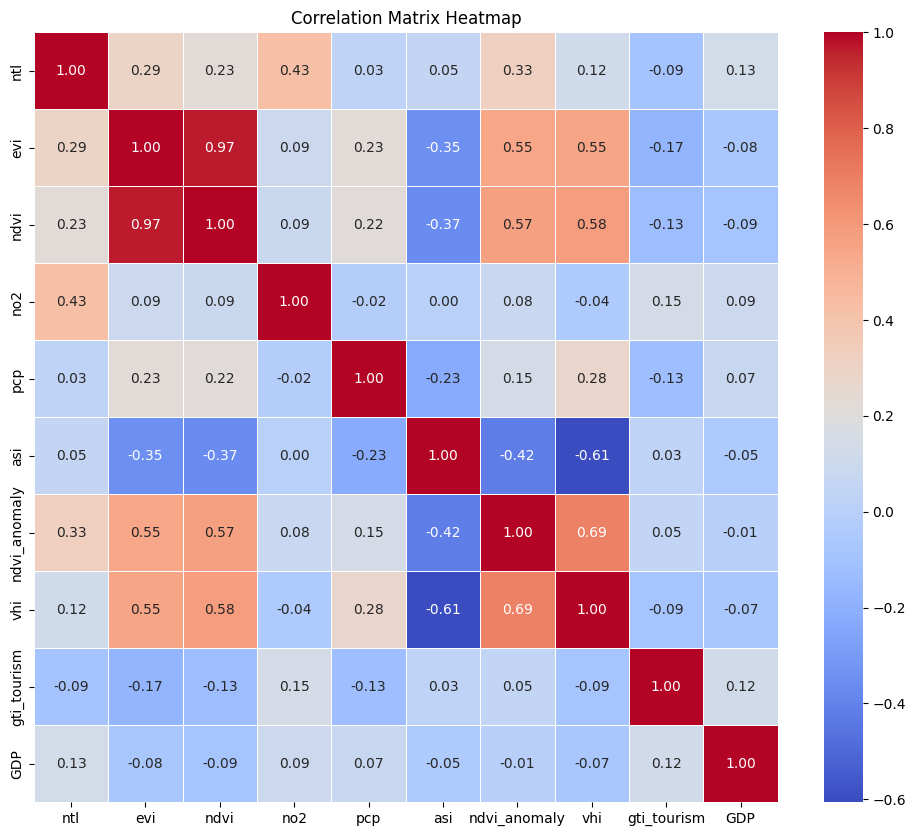

In [13]:
# Display the correlation matrix
df_ = df.copy()
df_.drop(df_.tail(2).index,inplace=True) # drop latest observation(s) where GDP is NaN
correlation_matrix = df_.corr(numeric_only=True)
display(correlation_matrix)

# Display the correlation matrix as a heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix Heatmap')
plt.show()

Visually explore data vs. GDP growth

In [14]:
import plotly.graph_objects as go

# Try with different indicators
indic1 = 'ntl'
indic2 = 'evi'

fig = go.Figure()

# Add first series (Trademarks Filings Growth)
fig.add_trace(go.Scatter(x=df_['index'], y=df_[indic1], mode='lines', name=indic1))

# Add second series (Designs Filings Growth)
fig.add_trace(go.Scatter(x=df_['index'], y=df_[indic2], mode='lines', name=indic2))

# Add third series (GDP) on a secondary y-axis
fig.add_trace(go.Scatter(x=df_['index'], y=df_['GDP'], mode='lines', name='GDP', yaxis='y2'))

# Update layout to include a secondary y-axis
fig.update_layout(
    title=f"{indic1} and {indic2} vs. GDP Growth for {CountryName}",
    xaxis_title='Date',
    yaxis_title='Growth Rate (%)',
    yaxis2=dict(
        title='GDP Growth Rate (%)',
        overlaying='y',
        side='right'
    )
)

fig.show()

## **Train the model**

### Initial training
**Split the data at 85:15 % train test, based on time series**

Fist drop observations where GDP growth is NaN

In [15]:
# For time series splits, reproducibility is typically handled by the data ordering itself.
# If using methods like train_test_split, a random_state would be used.
# 'index' is the name of the date column in the DataFrame
df_ = df.copy()
df_.drop(df_.tail(2).index,inplace=True) # drop latest observation(s) where GDP is NaN
# Include the quarter (index) column in the features before splitting
display(len(df_))

initial_window_size = len(df_.index) - 4 # Use all rows except the last 4 for training, the rest for testing

training = df_.iloc[:initial_window_size]
test = df_.iloc[initial_window_size:]

train_X = training.drop('GDP', axis=1)
train_y = training['GDP']
test_X = test.drop('GDP', axis=1)
test_y = test['GDP']

# Display resulting split data frames
#display(test_X.tail())
#display(test_y.tail())

# drop index column
train_X = train_X.drop('index', axis=1)
test_X = test_X.drop('index', axis=1)

51

**Train a RF model on the initial window (85% data)**

☝ **How do Random Forests models work?**
http://www.r2d3.us/visual-intro-to-machine-learning-part-1/

In [16]:
# train a random forest model
model = RandomForestRegressor(n_estimators=100, random_state=42) # hitchhikers guide to galaxy!

model.fit(train_X, train_y)

RandomForestRegressor(random_state=42)

### Predict on test dataset

,index,Actual,Predicted
47,2024-01-01,2.890688,2.934445
48,2024-04-01,3.143663,4.006032
49,2024-07-01,3.195526,3.960007
50,2024-10-01,4.352861,4.079472


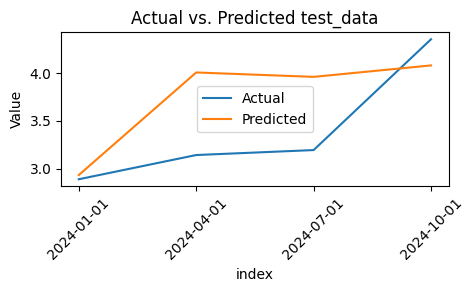

In [17]:
# Make predictions on the test data
predictions = model.predict(test_X)

# Create a DataFrame to display actual and predicted values alongside the index
comparison_df = pd.DataFrame({'index': test['index'], 'Actual': test_y, 'Predicted': predictions})

# Display the table
display(comparison_df)

# # Plot actual vs. predicted values with dates on the x-axis
plt.figure(figsize=(5, 2))
plt.plot(test['index'], test_y, label='Actual')
plt.plot(test['index'], predictions, label='Predicted')
plt.xlabel('index')
plt.ylabel('Value')
plt.title('Actual vs. Predicted test_data')
plt.legend()
plt.xticks(rotation=45)  # Rotate x-axis labels for better readability
plt.show()

### Generate error metrics, MAE and RMSE

In [18]:
# Calculate Mean Squared Error
mse = mean_squared_error(test_y, predictions)
mae = mean_absolute_error(test_y, predictions)

# Calculate Root Mean Squared Error
rmse = np.sqrt(mse)

print('Mean Squared Error:', mse)
print('Root Mean Squared Error:', rmse)
print("mean absolute error:", mae)

Mean Squared Error: 0.3511920696988968
Root Mean Squared Error: 0.592614604695916
mean absolute error: 0.48599901412118407


### Model explainability using shapley decomposition

**Summary values**

In [19]:
# Fits the explainer/Create object that can calculate shap values.
# (1) Create the 'explainer' using the model fit on the full training set, e.g. see (1) https://github.com/slundberg/shap (2) https://www.youtube.com/watch?v=CV9FTCvQ32Q (timestamp - 10:43)
# (2) Calculate shap values for the test set, e.g. (1) https://www.youtube.com/watch?v=ZkIxZ5xlMuI

explainer = shap.Explainer(model, seed=42) # same used by SHAP author, only include the model - https://github.com/slundberg/shap, note that xgb_model contains both preditor and target vaiables, so the explainer can understnad this realtionship
# Calculates the SHAP values. SHAP calculation time is lengthy, so your only choice is to run this on the test set, not the fulll data or train
# Note that this is being run on the test set
shap_values = explainer(test_X)


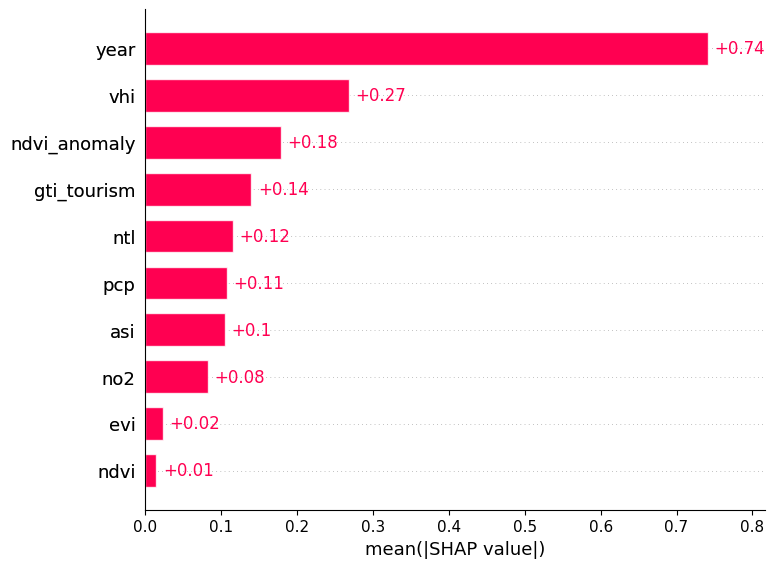

In [20]:
# Variable Importance Plot — Global Interpretability
#  A variable importance plot lists the most significant variables in descending order. The top variables contribute more to the model than the bottom ones and thus have high predictive power.
#shap.summary_plot(shap_values, test_X, plot_type="bar")

# SHAP Dependence Plot — Global Interpretability with contributing factors
shap.plots.bar(shap_values)

**Individual contributions**

Compare values in Shaply plot with predicted

In [21]:
display(comparison_df)
display(df.tail(6))

,index,Actual,Predicted
47,2024-01-01,2.890688,2.934445
48,2024-04-01,3.143663,4.006032
49,2024-07-01,3.195526,3.960007
50,2024-10-01,4.352861,4.079472


,index,year,ntl,evi,ndvi,no2,pcp,asi,ndvi_anomaly,vhi,gti_tourism,GDP
47,2024-01-01,2023,6.032283,8.521431,9.399115,-25.004804,66.972749,-74.706107,2.272942,-1.362309,-40.462315,2.890688
48,2024-04-01,2024,-25.689036,-95.509549,-95.547610,-3.856199,95.864678,87.696363,-17.502403,-15.907226,-3.908669,3.143663
49,2024-07-01,2024,-64.468383,-15.038930,-17.040362,19.097267,2.791961,57.865846,-19.561049,-14.705117,-26.580087,3.195526
50,2024-10-01,2024,-86.768883,-35.424417,-28.632328,-188.066217,-25.013640,75.219780,-15.552535,-10.434478,-15.062389,4.352861
51,2025-01-01,2024,-9.022241,11.796296,11.715487,-110.427821,-54.837019,40.436217,16.342595,30.908788,-6.451613,NaN
52,2025-04-01,2025,65.326793,1749.373233,1782.383110,46.801992,254.907679,-49.839386,-22.281404,-7.286102,-7.822712,NaN


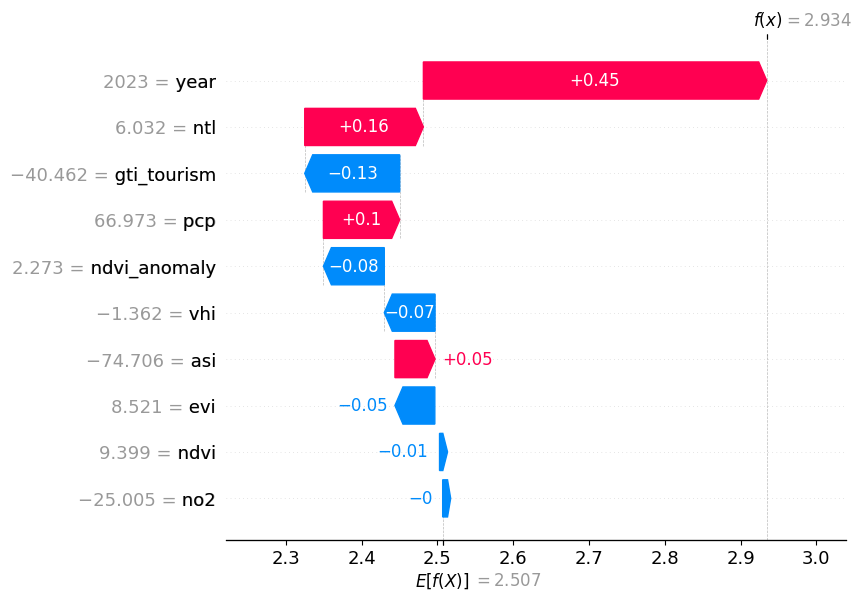

In [22]:
# SHAP waterfall plot for Explainable Contribution
shap.plots.waterfall(shap_values[0], show=True)


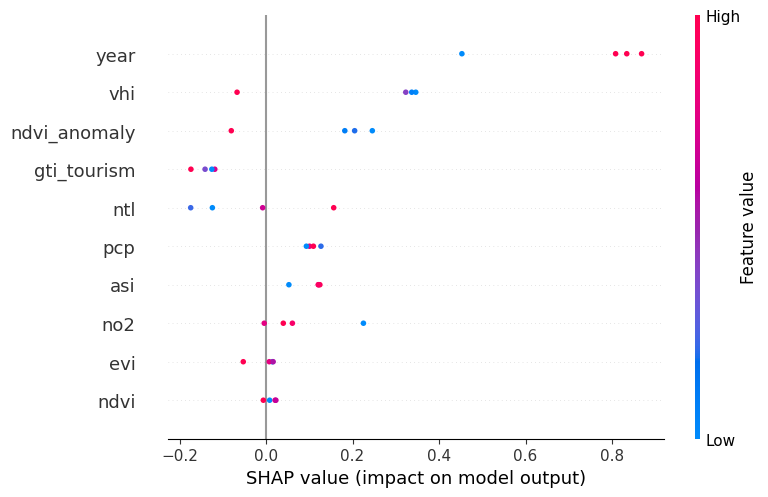

In [23]:
shap.plots.beeswarm(shap_values)

Explanation:

- Base Value (E[f(x)]): This is the average prediction of the model over the entire dataset. It's the starting point of the waterfall.

- SHAP Values (ϕ): Each row in the plot represents a feature from a single data point. The bars show the SHAP value for that feature for that specific prediction.

- Red bars: Indicate features that push the prediction higher than the base value.

- Blue bars: Indicate features that push the prediction lower than the base value.

- Output Value (f(x)): This is the final prediction of the model for the specific data point being explained. It's the ending point of the waterfall.

In [ ]:
# Explore all values
# display(shap_values)

**Partial Dependency Plots**

To visualize and analyze interaction between the target variable and a set of input features of interest. Assumes that the input features of interest are independent from the complement features, and this assumption is often violated in practice. Source: https://scikit-learn.org/stable/modules/partial_dependence.html

## **Retrain the model**

### **Retrain the model on rolling window**

Helper function: Define function for training and retraining models


In [24]:
def retrain_and_predict(data, model, window_size, horizon=1):
    """
    Trains a Random Forest model on a rolling window of data and predicts the next value.

    Args:
        data (pd.DataFrame): The full dataset with features and target.
        model (RandomForestRegressor): The scikit-learn model to retrain.
        window_size (int): The number of recent data points to train the model on.
        horizon (int): The number of future steps to predict.

    Returns:
        tuple: A tuple containing the updated model and the latest prediction.
    """
    # Define the training window
    train_data = data[-window_size:]

    # Separate features (X) and target (y)
    X_train = train_data.drop('GDP', axis=1)
    y_train = train_data['GDP']

    X_train = X_train.drop('index', axis=1) # drop index column

    # Retrain the model on the rolling window
    model.fit(X_train, y_train)

    # Prepare the latest available data for prediction
    latest_X = data.drop('GDP', axis=1).iloc[-horizon:]

    latest_X = latest_X.drop('index', axis=1)  # drop index column

    # Make the nowcast prediction
    nowcast = model.predict(latest_X)

    return model, nowcast

Simulate nowcasting loop with retraining

In [25]:
print("\n--- Simulating Retraining Loop ---")
rolling_window_size = initial_window_size + 4
num_retraining_steps = 4
predictions = []

for i in range(num_retraining_steps):
    # Simulate a new data point arriving
    new_data_point_index = initial_window_size + i
    new_df = df_.iloc[:new_data_point_index+1] #df_ is the copy of df without the NaN GDP rows

    # Retrain the model on the latest rolling window
    rf_model, new_prediction = retrain_and_predict(new_df, model, rolling_window_size)

    predictions.append(new_prediction[0])

    # Print results to show the nowcast adapting
    actual_value = df_['GDP'].iloc[new_data_point_index]

    print(f"Time Step: {df_.index[new_data_point_index]}")
    print(f"  Nowcast: {new_prediction[0]:.4f}")
    print(f"  Actual:  {actual_value:.4f}")
    print("-" * 20)

# --- Evaluate performance on the last predictions ---
actuals = df_['GDP'].iloc[initial_window_size : initial_window_size + num_retraining_steps]
rmse = np.sqrt(mean_squared_error(actuals, predictions))
print(f"\n--- Final Evaluation ---")
print(f"RMSE over the last {num_retraining_steps} predictions: {rmse:.4f}")


--- Simulating Retraining Loop ---
Time Step: 47
  Nowcast: 2.9014
  Actual:  2.8907
--------------------
Time Step: 48
  Nowcast: 3.5143
  Actual:  3.1437
--------------------
Time Step: 49
  Nowcast: 3.4025
  Actual:  3.1955
--------------------
Time Step: 50
  Nowcast: 4.0097
  Actual:  4.3529
--------------------

--- Final Evaluation ---
RMSE over the last 4 predictions: 0.2730


Predict the missing GDP growth value(s) using the retrained model

In [26]:
display(df.tail())

,index,year,ntl,evi,ndvi,no2,pcp,asi,ndvi_anomaly,vhi,gti_tourism,GDP
48,2024-04-01,2024,-25.689036,-95.509549,-95.547610,-3.856199,95.864678,87.696363,-17.502403,-15.907226,-3.908669,3.143663
49,2024-07-01,2024,-64.468383,-15.038930,-17.040362,19.097267,2.791961,57.865846,-19.561049,-14.705117,-26.580087,3.195526
50,2024-10-01,2024,-86.768883,-35.424417,-28.632328,-188.066217,-25.013640,75.219780,-15.552535,-10.434478,-15.062389,4.352861
51,2025-01-01,2024,-9.022241,11.796296,11.715487,-110.427821,-54.837019,40.436217,16.342595,30.908788,-6.451613,NaN
52,2025-04-01,2025,65.326793,1749.373233,1782.383110,46.801992,254.907679,-49.839386,-22.281404,-7.286102,-7.822712,NaN


In [27]:
# The last row(s) of the original dataframe 'df' contains the missing GDP value
latest_data = df.iloc[[-2]].copy() # we will predict the next period

In [28]:
display(latest_data)

,index,year,ntl,evi,ndvi,no2,pcp,asi,ndvi_anomaly,vhi,gti_tourism,GDP
51,2025-01-01,2024,-9.022241,11.796296,11.715487,-110.427821,-54.837019,40.436217,16.342595,30.908788,-6.451613,NaN


In [29]:
# Predict the missing GDP growth value using the retrained model

# Separate features (X) for prediction
X_latest = latest_data.drop('GDP', axis=1)
X_latest = X_latest.drop('index', axis=1) # drop index column

# Make the prediction
predicted_missing_gdp = model.predict(X_latest)

print(f"The predicted GDP growth for the missing period is: {predicted_missing_gdp[0]:.4f}")

The predicted GDP growth for the missing period is: 3.3212


### **Retrain the model on 100% of the data**

In [30]:
df_1 = df.copy()
df_1.drop(df_1.tail(2).index,inplace=True) # remove last 2 observations with NaN GDP


In [31]:
train_Xa, train_ya = df_1.iloc[:-1, 1:-1], df_1.iloc[:-1, -1]
test_Xa, test_ya = df_1.iloc[:, 1:-1], df_1.iloc[:, -1]

In [32]:
# Train Random Forest model
model_all = RandomForestRegressor(n_estimators=100, random_state=42)
model_all.fit(train_Xa, train_ya)

RandomForestRegressor(random_state=42)

In [33]:
predictions = model_all.predict(test_Xa)
# Calculate Mean Squared Error
mse = mean_squared_error(test_ya, predictions)
mae = mean_absolute_error(test_ya, predictions)

# Calculate Root Mean Squared Error
rmse = np.sqrt(mse)

print('Mean Squared Error:', mse)
print('Root Mean Squared Error:', rmse)
print("mean absolute error:", mae)

Mean Squared Error: 0.2931097983834055
Root Mean Squared Error: 0.5413961566019891
mean absolute error: 0.41470960033221715


Predict the missing GDP Growth using the model trained on 100% of the data

In [34]:
test_Xr = df.iloc[:, 1:-1]
test_Yr = df.iloc[:, -1]

In [35]:
# Make predictions on the test data
all_predictions = model_all.predict(test_Xr)


In [36]:
all_predictions

array([ 4.61552302,  4.99711437,  4.08719853,  4.62107215,  4.81980304,
        5.15740455,  5.84631902,  5.93433334,  6.21678527,  5.73821823,
        5.68441131,  4.95586894,  2.26184608,  2.00651009,  1.05333142,
        0.09831467, -0.47259338, -1.30596472, -1.09094647, -0.27377583,
        0.98894357,  0.94067596,  1.32888509,  2.13086685,  1.50097569,
        1.80667244,  2.04048841,  1.72206257,  1.59329299,  1.71447062,
        1.94038386,  0.96814997, -3.00216802, -1.21273138, -0.89251742,
       -0.12085695,  5.159607  ,  4.07932027,  3.93961744,  3.69151445,
        3.51438879,  2.76720162,  3.05683763,  2.66282546,  2.88565843,
        3.08511319,  2.83154054,  2.93379171,  3.54453614,  3.40249288,
        3.41849225,  2.98948131,  3.74169893])

### Compare model predictions

<h3> <b>❓ What method would you use to retrain the model?
</b>

In [37]:
# Compare predictions from both models. This time, predict all missing GDP values
comparison_df = df[['index', 'GDP']].copy()
comparison_df['initial_model_predictions'] = model.predict(df.drop(['index', 'GDP'], axis=1))
comparison_df['all_data_model_predictions'] = model_all.predict(df.drop(['index', 'GDP'], axis=1))

display(comparison_df)

,index,GDP,initial_model_predictions,all_data_model_predictions
0,2012-04-01,4.158733,4.556460,4.615523
1,2012-07-01,5.455796,5.000790,4.997114
2,2012-10-01,3.640100,3.927769,4.087199
3,2013-01-01,4.600034,4.607342,4.621072
4,2013-04-01,5.244072,4.641209,4.819803
5,2013-07-01,5.170594,5.005758,5.157405
6,2013-10-01,6.339123,5.887993,5.846319
7,2014-01-01,6.344540,5.951723,5.934333
8,2014-04-01,6.645603,6.199934,6.216785
9,2014-07-01,6.290359,5.743861,5.738218


### Plot model predictions

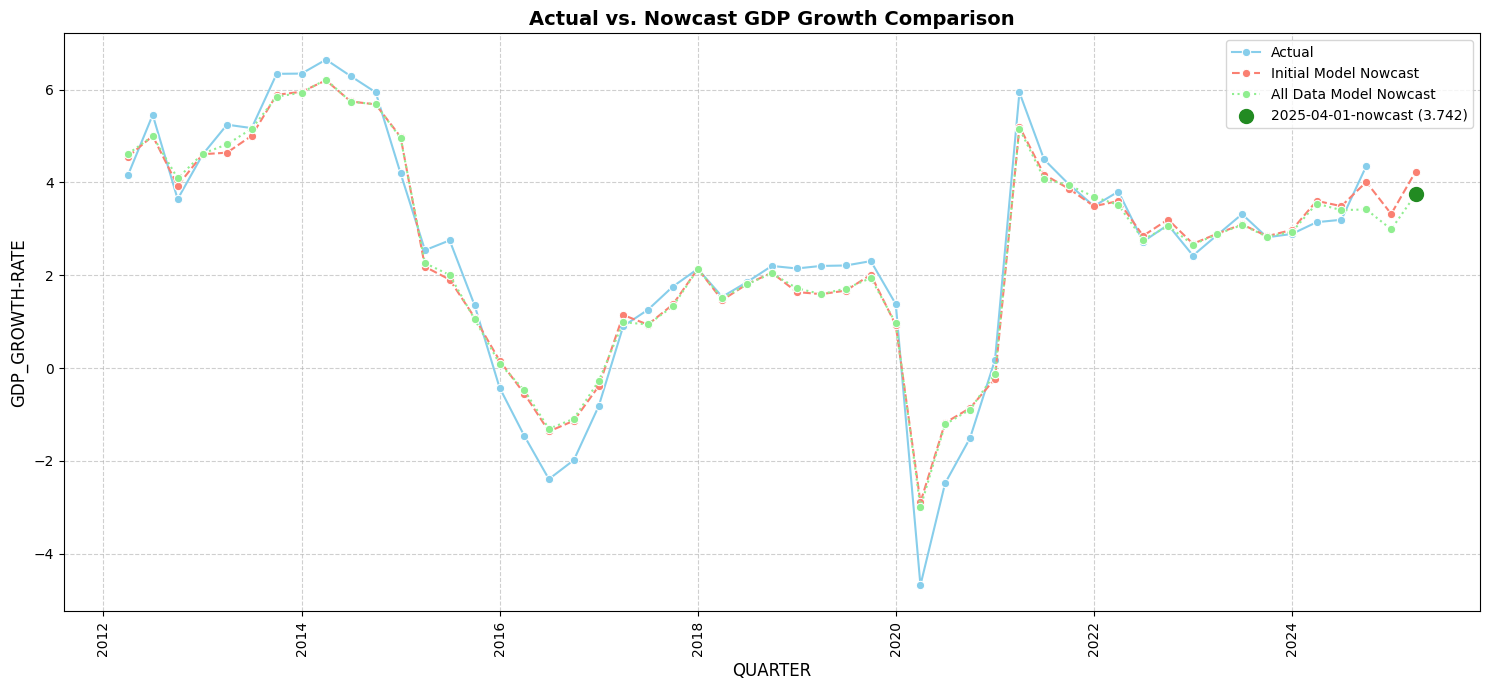

In [38]:
# Plot actual vs. predicted values with Years on the x-axis
# Convert 'index' to datetime if not already done (important for plotting time series)
comparison_df['index'] = pd.to_datetime(comparison_df['index'])

plt.figure(figsize=(15, 7)) # Increase figure size for better readability
sns.lineplot(data=comparison_df, x='index', y='GDP', label='Actual', marker='o', color='skyblue') # Use seaborn for nicer line plots and markers
sns.lineplot(data=comparison_df, x='index', y='initial_model_predictions', label='Initial Model Nowcast', linestyle='dashed', color='salmon', marker='o') # Plot initial model predictions
sns.lineplot(data=comparison_df, x='index', y='all_data_model_predictions', label='All Data Model Nowcast', linestyle='dotted', color='lightgreen', marker='o') # Plot all data model predictions


# Plot the last point from the 'all_data_model_predictions' with a distinct marker and label
last_row_all_data = comparison_df.iloc[[-1]].reset_index(drop=True)
plt.scatter(last_row_all_data['index'], last_row_all_data['all_data_model_predictions'], label=f"{last_row_all_data['index'].dt.strftime('%Y-%m-%d').iloc[0]}-nowcast ({last_row_all_data['all_data_model_predictions'].iloc[0]:.3f})", color='forestgreen', s=100, zorder=5) # Increase size and zorder for visibility, update label

plt.xlabel('QUARTER', fontsize=12) # Increase label font size
plt.ylabel('GDP_GROWTH-RATE', fontsize=12) # Increase label font size
plt.title('Actual vs. Nowcast GDP Growth Comparison', fontsize=14, fontweight='bold') # Increase title font size and add bold
plt.legend(fontsize=10) # Increase legend font size

plt.xticks(rotation=90, ha='center')  # Rotate x-axis labels vertically for better readability and center alignment
plt.grid(True, linestyle='--', alpha=0.6) # Add a grid for better readability
plt.tight_layout() # Adjust layout to prevent labels overlapping

plt.show()

Zoom in on the most recent observations

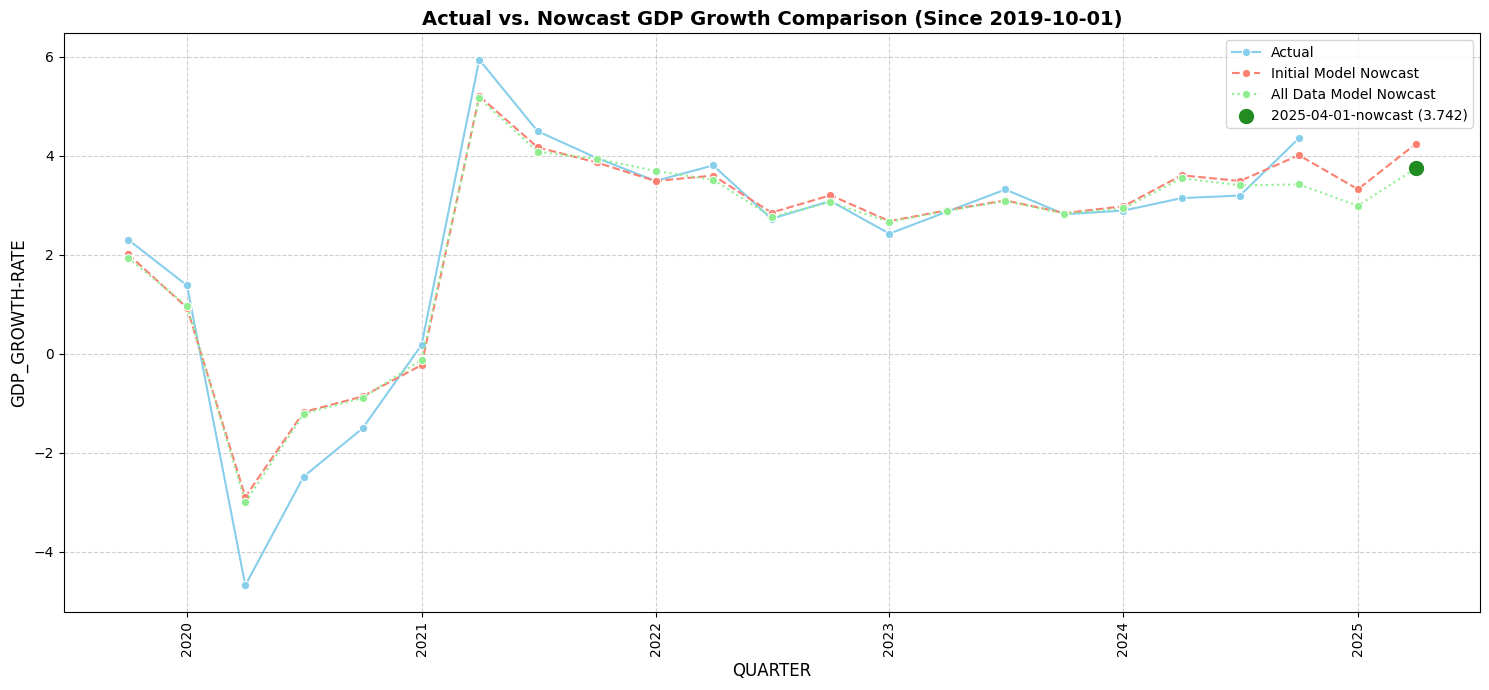

In [39]:
# Filter the DataFrame to include data from 2019-10-01 onwards
comparison_df_filtered = comparison_df[comparison_df['index'] >= '2019-10-01'].copy()

# Plot actual vs. predicted values with Years on the x-axis
last_row_filtered = comparison_df_filtered.iloc[[-1]].reset_index(drop=True)

plt.figure(figsize=(15, 7)) # Increase figure size for better readability
sns.lineplot(data=comparison_df_filtered, x='index', y='GDP', label='Actual', marker='o', color='skyblue') # Use seaborn for nicer line plots and markers
sns.lineplot(data=comparison_df_filtered, x='index', y='initial_model_predictions', label='Initial Model Nowcast', linestyle='dashed', color='salmon', marker='o') # Plot initial model predictions
sns.lineplot(data=comparison_df_filtered, x='index', y='all_data_model_predictions', label='All Data Model Nowcast', linestyle='dotted', color='lightgreen', marker='o') # Plot all data model predictions

# Plot the last point from the 'all_data_model_predictions' with a distinct marker and label
plt.scatter(last_row_filtered['index'], last_row_filtered['all_data_model_predictions'], label=f"{last_row_filtered['index'].dt.strftime('%Y-%m-%d').iloc[0]}-nowcast ({last_row_filtered['all_data_model_predictions'].iloc[0]:.3f})", color='forestgreen', s=100, zorder=5) # Increase size and zorder for visibility, update label

plt.xlabel('QUARTER', fontsize=12) # Increase label font size
plt.ylabel('GDP_GROWTH-RATE', fontsize=12) # Increase label font size
plt.title('Actual vs. Nowcast GDP Growth Comparison (Since 2019-10-01)', fontsize=14, fontweight='bold') # Increase title font size and add bold
plt.legend(fontsize=10) # Increase legend font size

plt.xticks(rotation=90, ha='center')  # Rotate x-axis labels vertically for better readability and center alignment
plt.grid(True, linestyle='--', alpha=0.6) # Add a grid for better readability
plt.tight_layout() # Adjust layout to prevent labels overlapping

plt.show()

### Save predictions and the model

In [57]:
df_to_save=df_imported.copy() # df_imported is the original model we read
df_to_save["predicted_gdp"]=all_predictions # add predicted GDP from the 100% retrained
df_to_save = df_to_save[['index','GDP','predicted_gdp']]
df_to_save.to_csv('saved_data.csv')
df_to_save

,index,GDP,predicted_gdp
0,2012-04-01,4.158733,4.161858
1,2012-07-01,5.455796,4.585025
2,2012-10-01,3.640100,4.271069
3,2013-01-01,4.600034,4.133836
4,2013-04-01,5.244072,4.428531
5,2013-07-01,5.170594,4.493180
6,2013-10-01,6.339123,5.026521
7,2014-01-01,6.344540,5.140250
8,2014-04-01,6.645603,5.070414
9,2014-07-01,6.290359,5.097598


Save the predictions to a file

In [58]:
filename = 'nga_pred_data.csv'
filepath = os.path.join(data_path, filename)

df_to_save.to_csv(filepath, index=False)


Save the model to a file

In [59]:
filename = 'model_nga.pkl'
filepath = os.path.join(data_path, filename)

with open(filepath, 'wb') as f:
    pickle.dump(model, f)


## Advanced: Hyperparameter tuning

So far we have trained a plain vanilla Random Forest model. In a real use case, we would like to scale up results by using C-V. We cover the following:

- Random vs. custom splits
- Grid search vs. Random search

Source: https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestRegressor.html

### **Grid search with random splits**

⚠ This may take long to run depending on the number of parameter values combinations

In [51]:
# prepare the dataset
df_1 = df.copy()
df_1.drop(df_1.tail(2).index,inplace=True)
train_Xa, train_ya = df_1.iloc[:-1, 1:-1], df_1.iloc[:-1, -1]
test_Xa, test_ya = df_1.iloc[:, 1:-1], df_1.iloc[:, -1]

In [52]:
# Define the Random Forest model
model = RandomForestRegressor(random_state=42)

# Define hyperparameters and their possible values
param_grid = {
    'n_estimators': [100, 200, 300],  # Number of trees in the forest
    'max_depth': [None, 10, 20, 30],  # Maximum depth of the tree
    'min_samples_split': [2, 5, 10],  # Minimum number of samples required to split
    'min_samples_leaf': [1, 2, 4],    # Minimum number of samples at each leaf node
    'max_features': ['auto', 'sqrt']  # Number of features considered at each split
}

# Set up TimeSeriesSplit
tscv = TimeSeriesSplit(n_splits=5)  # Adjust n_splits as needed

# Set up GridSearchCV with TimeSeriesSplit
grid_search = GridSearchCV(estimator=model, param_grid=param_grid,
                           cv=tscv, scoring='neg_mean_squared_error',
                           verbose=2, n_jobs=-1)

# Perform the Grid Search
grid_search.fit(train_Xa, train_ya)

# Get the best parameters
print("Best Hyperparameters:", grid_search.best_params_)

# Evaluate the best model on the test set
best_model = grid_search.best_estimator_
y_pred = best_model.predict(test_Xa)
mse = mean_squared_error(test_ya, y_pred)
mae=mean_absolute_error(test_ya, y_pred)
rmse = np.sqrt(mse)

print('Mean Squared Error:', mse)
print('Root Mean Squared Error:', rmse)
print("mean absolute error:", mae)

# Train final model on the full training data if needed
final_model_grid_ran = RandomForestRegressor(**grid_search.best_params_)
final_model_grid_ran.fit(train_Xa, train_ya)

Fitting 5 folds for each of 216 candidates, totalling 1080 fits
Best Hyperparameters: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 300}
Mean Squared Error: 1.0996885367206353
Root Mean Squared Error: 1.0486603533654903
mean absolute error: 0.7410847431720475


RandomForestRegressor(max_features='sqrt', min_samples_leaf=2, n_estimators=300)

### **Grid search with custom splits**

In [53]:
# Define the Random Forest model
model = RandomForestRegressor(random_state=42)

# Define hyperparameters and their possible values
param_grid = {
    'n_estimators': [100, 200, 300],  # Number of trees in the forest
    'max_depth': [None, 10, 20, 30],  # Maximum depth of the tree
    'min_samples_split': [2, 5, 10],  # Minimum number of samples required to split
    'min_samples_leaf': [1, 2, 4],    # Minimum number of samples at each leaf node
    'max_features': ['auto', 'sqrt']  # Number of features considered at each split
}

# Function to create custom TimeSeriesSplit with increasing training set sizes
def custom_timeseries_split(X, y, n_splits=5):
    n_samples = len(X)
    splits = []
    for i in range(n_splits):
        train_size = int(n_samples * (0.7 + i * 0.05))
        train_index = list(range(train_size))
        test_index = list(range(train_size, n_samples))
        splits.append((train_index, test_index))

    return splits

# Create custom TimeSeriesSplit
custom_splits = custom_timeseries_split(train_Xa, train_ya, n_splits=5)
# Set up GridSearchCV with custom TimeSeriesSplit
grid_search = GridSearchCV(estimator=model, param_grid=param_grid,
                           cv=custom_splits, scoring='neg_mean_squared_error',
                           verbose=2, n_jobs=-1)

# Perform the Grid Search
grid_search.fit(train_Xa, train_ya)

# Get the best parameters
print("Best Hyperparameters:", grid_search.best_params_)

# Evaluate the best model on the test set
best_model = grid_search.best_estimator_
y_pred = best_model.predict(test_Xa)
mse = mean_squared_error(test_ya, y_pred)
mae=mean_absolute_error(test_ya, y_pred)
rmse = np.sqrt(mse)

print('Mean Squared Error:', mse)
print('Root Mean Squared Error:', rmse)
print("mean absolute error:", mae)

# Train final model on the full training data if needed
final_model_grid_cust = RandomForestRegressor(**grid_search.best_params_)
final_model_grid_cust.fit(train_Xa, train_ya)

Fitting 5 folds for each of 216 candidates, totalling 1080 fits
Best Hyperparameters: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 200}
Mean Squared Error: 2.4099062074815696
Root Mean Squared Error: 1.5523872607959555
mean absolute error: 1.1108114133446136


RandomForestRegressor(max_features='sqrt', min_samples_leaf=4,
                      min_samples_split=10, n_estimators=200)

### **Random search with random splits**

Random search will speed up the grid search

In [54]:
# Define the Random Forest model
model = RandomForestRegressor(random_state=42)

# Define hyperparameters and their possible ranges
param_distributions = {
    'n_estimators': [int(x) for x in np.linspace(start=100, stop=500, num=10)],  # Random range
    'max_depth': [None, 10, 20, 30, 40, 50],
    'min_samples_split': [2, 5, 10, 15],
    'min_samples_leaf': [1, 2, 4, 8],
    'max_features': ['auto', 'sqrt', 'log2']
}

# Set up TimeSeriesSplit
tscv = TimeSeriesSplit(n_splits=5)  # Adjust n_splits as needed

# Set up RandomizedSearchCV with TimeSeriesSplit
random_search = RandomizedSearchCV(estimator=model, param_distributions=param_distributions,
                                   n_iter=50, cv=tscv, scoring='neg_mean_squared_error',
                                   verbose=2, random_state=42, n_jobs=-1)

# Perform the Randomized Search
random_search.fit(train_Xa, train_ya)

# Get the best parameters
print("Best Hyperparameters:", random_search.best_params_)

# Evaluate the best model on the test set
best_model = random_search.best_estimator_
y_pred = best_model.predict(test_Xa)
mse = mean_squared_error(test_ya, y_pred)
mae = mean_absolute_error(test_ya, y_pred)
rmse = np.sqrt(mse)

print('Mean Squared Error:', mse)
print('Root Mean Squared Error:', rmse)
print("mean absolute error:", mae)

# Train final model on the full training data if needed
final_model_ran_ran = RandomForestRegressor(**random_search.best_params_)
final_model_ran_ran.fit(train_Xa, train_ya)

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best Hyperparameters: {'n_estimators': 233, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 'log2', 'max_depth': 30}
Mean Squared Error: 1.1084041633864254
Root Mean Squared Error: 1.0528077523396309
mean absolute error: 0.7451597108116021


RandomForestRegressor(max_depth=30, max_features='log2', min_samples_leaf=2,
                      n_estimators=233)

### **Random search with custom splits**

In [55]:
# Function to create custom TimeSeriesSplit with increasing training set sizes
def custom_timeseries_split(X, y, n_splits=5):
    n_samples = len(X)
    splits = []
    for i in range(n_splits):
        train_size = int(n_samples * (0.7 + i * 0.05))
        train_index = list(range(train_size))
        test_index = list(range(train_size, n_samples))
        splits.append((train_index, test_index))
    return splits

# Example usage (assuming train_Xa and train_ya are defined)
custom_splits = custom_timeseries_split(train_Xa, train_ya, n_splits=5)

# Define the Random Forest model
model = RandomForestRegressor(random_state=42)

# Define hyperparameters and their possible ranges
param_distributions = {
    'n_estimators': [int(x) for x in np.linspace(start=100, stop=500, num=10)],  # Random range
    'max_depth': [None, 10, 20, 30, 40, 50],
    'min_samples_split': [2, 5, 10, 15],
    'min_samples_leaf': [1, 2, 4, 8],
    'max_features': ['auto', 'sqrt', 'log2']
}

# Set up RandomizedSearchCV with custom TimeSeriesSplit
random_search = RandomizedSearchCV(estimator=model, param_distributions=param_distributions,
                                   n_iter=50, cv=custom_splits, scoring='neg_mean_squared_error',
                                   verbose=2, random_state=42, n_jobs=-1)

# Perform the Randomized Search
random_search.fit(train_Xa, train_ya)

# Get the best parameters
print("Best Hyperparameters:", random_search.best_params_)

# Evaluate the best model on test set
best_model = random_search.best_estimator_
y_pred = best_model.predict(test_Xa)
mse = mean_squared_error(test_ya, y_pred)
mae = mean_absolute_error(test_ya, y_pred)
rmse = np.sqrt(mse)

print('Mean Squared Error:', mse)
print('Root Mean Squared Error:', rmse)
print("mean absolute error:", mae)

# Train final model
final_model_ran_cust = RandomForestRegressor(**random_search.best_params_)
final_model_ran_cust.fit(train_Xa, train_ya)

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best Hyperparameters: {'n_estimators': 188, 'min_samples_split': 15, 'min_samples_leaf': 8, 'max_features': 'log2', 'max_depth': 10}
Mean Squared Error: 3.9131544529447115
Root Mean Squared Error: 1.9781694702286534
mean absolute error: 1.4441748796608547


RandomForestRegressor(max_depth=10, max_features='log2', min_samples_leaf=8,
                      min_samples_split=15, n_estimators=188)

**Plot results**

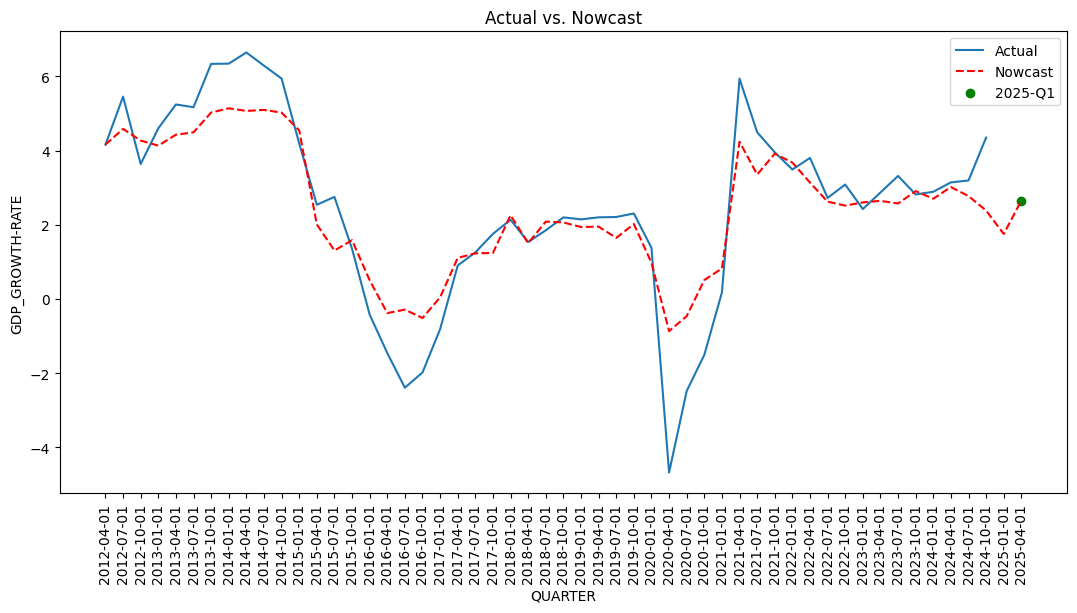

In [60]:
test_Xr = df.iloc[:, 1:-1]
test_Yr = df.iloc[:, -1]

# Choose the model from the above:
# final_model_grid_ran
# final_model_grid_cust
# final_model_ran_ran
# final_model_ran_cust
model_toplot = final_model_ran_ran

all_predictions = model_toplot.predict(test_Xr)
# Plot actual vs. predicted values with Years on the x-axis
last_row_df = df_to_save.iloc[[-1]].reset_index(drop=True)
plt.figure(figsize=(13, 6))
#df_to_save.drop(df_to_save.tail(1).index,inplace=True)
plt.plot(df_to_save['index'], df_to_save['GDP'], label='Actual')
plt.plot(df_to_save['index'], df_to_save['predicted_gdp'], label='Nowcast',linestyle='dashed', color='red')
#plt.plot(df_to_save['index'], df_to_save['predicted_gdp'], label='2024-Q1',linestyle='dashed', color='red')
plt.scatter(last_row_df['index'], last_row_df['predicted_gdp'], label='2025-Q1', color='green')
plt.xlabel('QUARTER')
plt.ylabel('GDP_GROWTH-RATE')
plt.title('Actual vs. Nowcast')
plt.legend()
plt.xticks(rotation=90)  # Rotate x-axis labels for better readability
plt.show()

<h3> <b>❓ Did the results improve when we introduced a more complex parameter grid search?
</b>

## Other models

scikit learn makes available a wide range of models. For details: https://scikit-learn.org/stable/api/sklearn.ensemble.html

## Summary

This notebook demonstrates how to build and evaluate a nowcasting model for GDP growth using satellite data and machine learning, specifically focusing on Nigeria. The key steps covered include:

1.  **Data Loading and Processing**: The notebook starts by loading pre-processed data, which includes satellite-derived indicators and Google Trends data, along with the target variable, GDP growth. The data is cleaned and prepared for modeling.
2.  **Exploratory Data Analysis**: Correlation analysis and visualizations are used to understand the relationships between the different indicators and GDP growth.
3.  **Initial Model Training and Evaluation**: A Random Forest Regressor model is trained on an initial split of the time-series data (85% train, 15% test). The model's performance is evaluated using metrics like Mean Squared Error (MSE), Root Mean Squared Error (RMSE), and Mean Absolute Error (MAE).
4.  **Model Explainability**: SHAP (SHapley Additive exPlanations) values are calculated and visualized to understand the contribution of each feature to the model's predictions.
5.  **Model Retraining and Nowcasting**: The notebook demonstrates two approaches to retraining the model:
    *   **Rolling Window**: The model is retrained on a rolling window of the most recent data, simulating a real-world nowcasting scenario where new data becomes available.
    *   **Full Data**: The model is retrained on the entire available dataset.
6.  **Prediction of Missing Values**: The retrained models are used to predict the missing GDP growth values in the latest periods.
7.  **Comparison and Visualization of Predictions**: The predictions from the different models are compared visually against the actual GDP growth values to assess their performance.
8.  **Model and Prediction Saving**: The final predictions and the trained model are saved to files for future use.
9.  **Hyperparameter Tuning (Advanced)**: The notebook explores advanced techniques for improving model performance through hyperparameter tuning using GridSearchCV and RandomizedSearchCV with different cross-validation strategies (random and custom time series splits).
10. **Other Models**: Briefly mentions that other scikit-learn models can be explored for this task.

Overall, this notebook provides a comprehensive workflow for building, evaluating, explaining, and deploying a machine learning model for GDP nowcasting using alternative data sources.